# Weather-object datasets

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

The function used to assign coordiantes for weather object dataset

In [2]:
def assign_weatherfeature_coords(ds):
    # suqeeze
    ds = ds.squeeze()
    
    # get names of y and x dims
    y_dim = list(ds.dims)[1]
    x_dim = list(ds.dims)[2]
    
    # get numbers of y and x dims
    ny = ds.sizes[y_dim]
    nx = ds.sizes[x_dim]
    
    # assign coords
    lat_vals = np.arange(-90, 90.5, 0.5)
    lon_vals = -180 + 0.5 * np.arange(nx)
    ds = ds.assign_coords({y_dim: (y_dim, lat_vals)})
    ds = ds.assign_coords({x_dim: (x_dim, lon_vals)})
    
    # rename y- and x-coordiante as lat and lon
    ds = ds.rename({y_dim: 'latitude', x_dim: 'longitude'})

    # check longitude
    if ds.longitude.size != 720:
        ds = ds.sel(longitude=np.arange(-180, 180, .5))

    return ds

In [27]:
# directories
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
datadir = f'{workdir}/data/weatherfeatures.era5'
maskdir = '/scratch/if69/cj0591/state_mask05.nc'

In [29]:
# one month exmaple
year = 2020; month = 1

# cyclone
cyclone = xr.open_dataset(f'{datadir}/mincl/cdf/{year}/C{year}_{str(month).zfill(2)}.nc')
cyclone = assign_weatherfeature_coords(cyclone).sel(latitude=slice(-55, -9),longitude=slice(110, 155))

# anticyclone
anticyclone = xr.open_dataset(f'{datadir}/maxcl/cdf/{year}/A{year}_{str(month).zfill(2)}.nc')
anticyclone = assign_weatherfeature_coords(anticyclone).sel(latitude=slice(-55, -9),longitude=slice(110, 155))

# front
front = xr.open_dataset(f'{datadir}/fronts/cdf.700hPa/{year}/F{year}_{str(month).zfill(2)}.nc')
front = assign_weatherfeature_coords(front).sel(latitude=slice(-55, -9),longitude=slice(110, 155))

# wcb
wcb = xr.open_dataset(f'{datadir}/wcb/cdf.1hourly/{year}/hit_{year}_{str(month).zfill(2)}.nc')
wcb = assign_weatherfeature_coords(wcb).sel(latitude=slice(-55, -9),longitude=slice(110, 155))

# mask
masks = xr.open_dataset(maskdir)

At an instantaneous timestep

Text(0.5, 1.0, '2020-01-01T22 | Full')

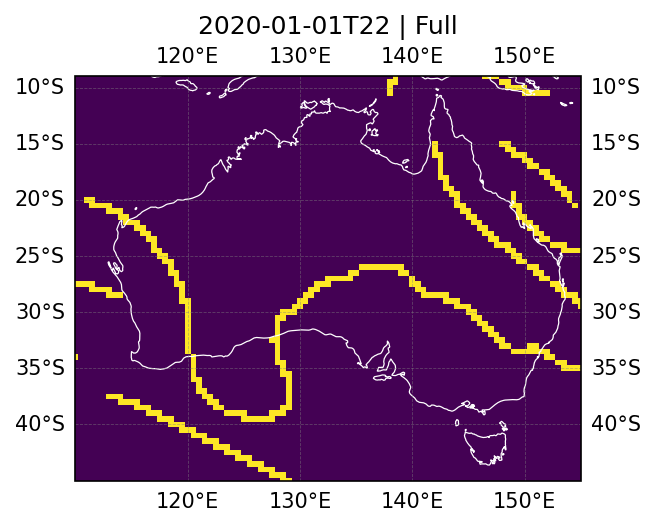

In [60]:
single = front['FRONT'].isel(time=22)
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
# plot object
single.plot(ax=ax, transform=datacrs, add_colorbar=False)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='w', lw=.6)
ax.set_extent([110, 155, -45, -9], crs=datacrs)
ax.set_title(f'{str(single.time.values)[0:13]} | Full')

Text(0.5, 1.0, '2020-01-01T22 | QLD-only Front')

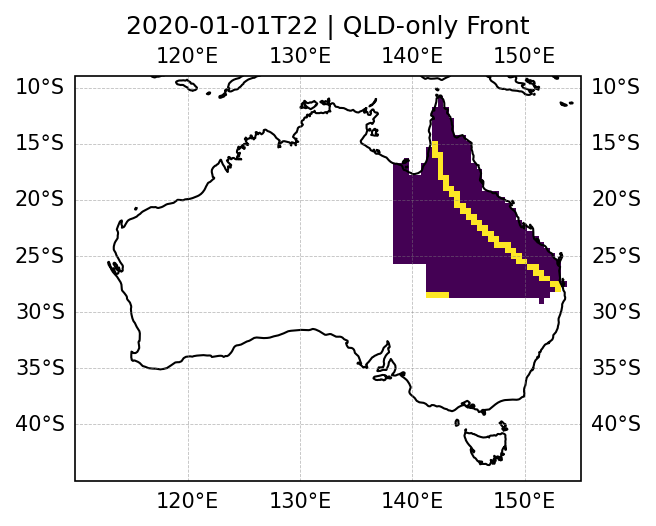

In [59]:
# object but only in a state
single = (front['FRONT'].where(masks["QLD"] == 1)).isel(time=22)
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
# plot object
single.plot(ax=ax, transform=datacrs, add_colorbar=False)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='k', lw=1)
ax.set_extent([110, 155, -45, -9], crs=datacrs)
ax.set_title(f'{str(single.time.values)[0:13]} | QLD-only Front')

Fraction of grid covered by a weather object

In [51]:
# first get the grid numbers of a state
n_grids = masks["NSW"].sum(("latitude", "longitude")).values

cyclone_ts = (
    cyclone["INPUT"]
    .where(masks["NSW"] == 1)
    .sum(("latitude", "longitude"))
) / n_grids

anticyclone_ts = (
    anticyclone["FLAG"]
    .where(masks["NSW"] == 1)
    .sum(("latitude", "longitude"))
) / n_grids

front_ts = (
    front["FRONT"]
    .where(masks["NSW"] == 1)
    .sum(("latitude", "longitude"))
) / n_grids

wcb_ts = (
    wcb["MIDTROP"]
    .where(masks["NSW"] == 1)
    .sum(("latitude", "longitude"))
) / n_grids

subset and occurrence over a region

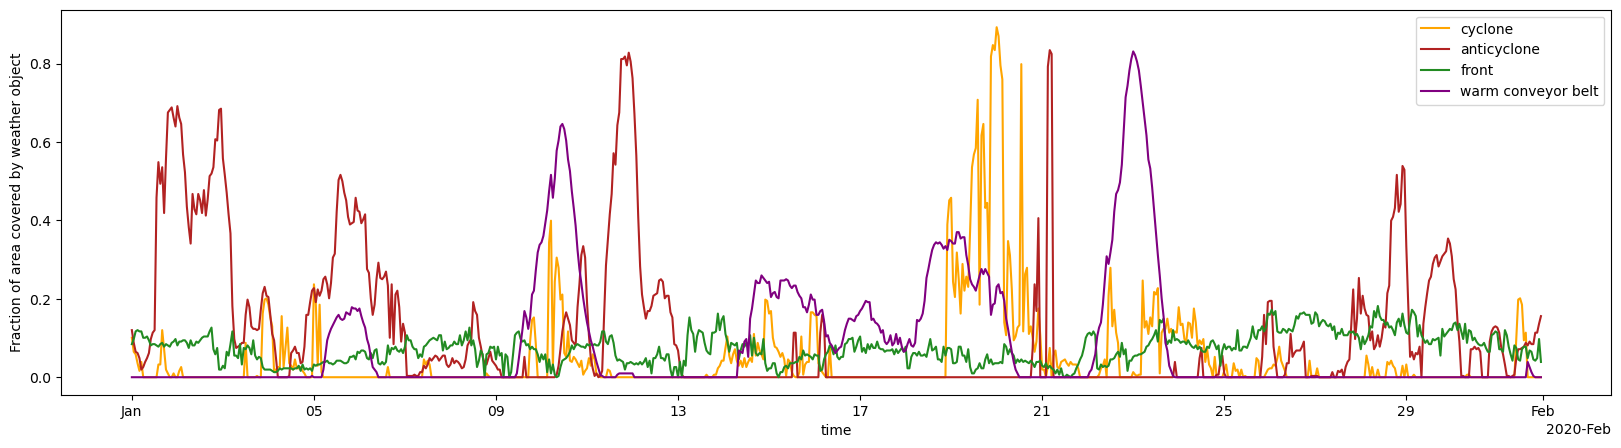

In [58]:
fig, ax = plt.subplots(figsize=(20, 5))

cyclone_ts.plot(color='orange', label='cyclone')
anticyclone_ts.plot(color='firebrick', label='anticyclone')
front_ts.plot(color='forestgreen', label='front')
wcb_ts.plot(color='purple', label='warm conveyor belt')
ax.set_ylabel('Fraction of area covered by weather object')

plt.legend()

# 